# Code

In [1]:
from typing import List, Dict

In [2]:
class RotatedSurfaceCodePatch:
    def __init__(self,
                 code_distance: int,
                 x_offset: int = 0,
                 y_offset: int = 0,
                 index_offset: int = 0):
        self.code_distance    = code_distance
        self.data_coords      = []
        self.x_measure_coords = []
        self.z_measure_coords = []
        self.logical_x_coords = []  # data qubits along top row for logical X
        self.logical_z_coords = []  # data qubits along left column for logical Z

        self.left_boundary_x   = 0 + x_offset
        self.right_boundary_x  = self.left_boundary_x + code_distance
        self.top_boundary_y    = 0 + y_offset
        self.bottom_boundary_y = self.top_boundary_y + code_distance

        self.coord_to_index = {}
        self.data_indices: List[int]
        self.x_anc_indices: List[int]
        self.z_anc_indices: List[int]
        self.meas_indices: List[int]
        #IK: added
        self.data_xtarget_indices: List[List[int]]

        self.def_x_order = [0.5+0.5j, -0.5+0.5j, 0.5-0.5j, -0.5-0.5j]  # NE, NW, SE, SW for X stabilizers
        self.def_z_order = [0.5+0.5j,  0.5-0.5j, -0.5+0.5j, -0.5-0.5j]  # NE, SE, NW, SW for Z stabilizers

        self.x_anc_neighbors: Dict[int, List[int]] = {}
        self.z_anc_neighbors: Dict[int, List[int]] = {}

        # Data qubits
        for x in range(code_distance):
            for y in range(code_distance):
                q = complex(x + 0.5 + x_offset, y + 0.5 + y_offset)  # data qubit coordinate
                self.data_coords.append(q)
                if x == 0:  # first row
                    self.logical_x_coords.append(q)
                if y == 0:  # first column
                    self.logical_z_coords.append(q)

        # Ancilla qubits at integer coords: parity True -> X stabilizer, False -> Z stabilizer
        for x in range(code_distance + 1):
            for y in range(code_distance + 1):
                q = complex(x + x_offset, y + y_offset)
                parity = (x % 2) != (y % 2)
                on_boundary1 = (x == 0 or x == code_distance)
                on_boundary2 = (y == 0 or y == code_distance)
                if on_boundary1 and parity:
                    continue  # skip X ancillas on boundary
                if on_boundary2 and not parity:
                    continue  # skip Z ancillas on opposite boundary
                if parity:
                    self.x_measure_coords.append(q)
                else:
                    self.z_measure_coords.append(q)

        self.data_coords.sort(key=lambda c: (c.real, c.imag))
        self.x_measure_coords.sort(key=lambda c: (c.real, c.imag))
        self.z_measure_coords.sort(key=lambda c: (c.real, c.imag))


        idx = 0
        for q in self.data_coords + self.x_measure_coords + self.z_measure_coords:
            self.coord_to_index[q] = idx + index_offset
            idx += 1


        self.data_indices  = [self.coord_to_index[q] for q in self.data_coords]
        self.x_anc_indices = [self.coord_to_index[q] for q in self.x_measure_coords]
        self.z_anc_indices = [self.coord_to_index[q] for q in self.z_measure_coords]
        self.meas_indices  = self.x_anc_indices + self.z_anc_indices  # list of all ancilla qubit indices

        # Map qubit index to measurement order position
        self.meas_index_map = {q_idx: i for i, q_idx in enumerate(self.meas_indices)}
        self.data_index_map = {q_idx: i for i, q_idx in enumerate(self.data_indices)}

        def add_item ( key, val, connections ):
            connections[ key ] = [ val ] + ( connections[ key ] if key in connections.keys() else [  ] )

        for k in range(4):
            # 
            # X stabilizer: ancilla (control) -> data (target)
            for anc_coord in self.x_measure_coords:
                neighbor = anc_coord + self.def_x_order[k]
                if neighbor in self.coord_to_index and neighbor in self.data_coords:
                    anc = self.coord_to_index[anc_coord]; data = self.coord_to_index[neighbor]
                    add_item(anc, data, self.x_anc_neighbors)

            # Z stabilizer: data (control) -> ancilla (target)
            for anc_coord in self.z_measure_coords:
                neighbor = anc_coord + self.def_z_order[k]
                if neighbor in self.coord_to_index and neighbor in self.data_coords:
                    data = self.coord_to_index[neighbor]; anc = self.coord_to_index[anc_coord]
                    anc = self.coord_to_index[anc_coord]; data = self.coord_to_index[neighbor]
                    add_item(anc, data, self.z_anc_neighbors)


    def stabilizer_measurement(self,
                               x_order_in: List[complex]|None = None,
                               z_order_in: List[complex]|None = None) -> List[List[complex]]:

        x_order = x_order_in if x_order_in else self.def_x_order
        z_order = z_order_in if z_order_in else self.def_z_order

        ret = []
        # IK: added
        self.data_xtarget_indices = [] # length will be 4
        for k in range(4):
            targets = []
            data_xtarget = []
            # X stabilizer: ancilla (control) -> data (target)
            for anc_coord in self.x_measure_coords:
                neighbor = anc_coord + x_order[k]
                if neighbor in self.coord_to_index and neighbor in self.data_coords:
                    anc = self.coord_to_index[anc_coord]; data = self.coord_to_index[neighbor]
                    targets += [anc, data]
                    # IK: added
                    data_xtarget.append(data)
            # IK: added
            self.data_xtarget_indices.append(data_xtarget)


            # Z stabilizer: data (control) -> ancilla (target)
            for anc_coord in self.z_measure_coords:
                neighbor = anc_coord + z_order[k]
                if neighbor in self.coord_to_index and neighbor in self.data_coords:
                    data = self.coord_to_index[neighbor]; anc = self.coord_to_index[anc_coord]
                    targets += [data, anc]

            ret.append(targets)

        return ret

    def first_round_detectors(self, memory_basis: str = 'Z') -> List[tuple[int, complex]]:
        if memory_basis == 'Z':
            measure_coords = self.z_measure_coords
        elif memory_basis == 'X':
            measure_coords = self.x_measure_coords
        else:
            print("memory_basis should be 'X' or 'Z'")
            assert(0)

        ret = []
        for anc_coord in measure_coords:
            anc = self.coord_to_index[anc_coord]
            j = self.meas_index_map[anc]  # position in measurement list
            ret.append((j - self.num_meas, anc_coord))

        return ret

    def round_detectors(self) -> List[tuple[int, int, complex]]:
        ret = []
        for anc_coord in (self.x_measure_coords + self.z_measure_coords):
            anc_idx = self.coord_to_index[anc_coord]
            j = self.meas_index_map[anc_idx]
            ret.append((j - self.num_meas, j - 2 * self.num_meas, anc_coord))

        return ret

    def round_detectors_mod(self) -> List[tuple[int, complex]]:
        ret = []
        for anc_coord in (self.x_measure_coords + self.z_measure_coords):
            anc_idx = self.coord_to_index[anc_coord]
            j = self.meas_index_map[anc_idx]
            ret.append((j - self.num_meas, anc_coord))

        return ret


    def final_round_measurement(self, memory_basis: str = 'Z') -> List[tuple[List[int], complex]]:
        if memory_basis == 'Z':
            measure_coords = self.z_measure_coords
            delta_order = self.def_z_order ### TODO check variable
        elif memory_basis == 'X':
            measure_coords = self.x_measure_coords
            delta_order = self.def_x_order ### TODO check variable
        else:
            print("memory_basis should be 'X' or 'Z'")
            assert(0)

        ret = []
        for anc_coord in measure_coords:
            anc = self.coord_to_index[anc_coord]
            j = self.meas_index_map[anc]
            det_targets = []
            # Include all data measurements that belonged to this Z stabilizer

            for delta in delta_order:
                data_coord = anc_coord + delta
                if data_coord in self.coord_to_index and data_coord in self.data_coords:
                    di = self.coord_to_index[data_coord]
                    pos = self.data_index_map[di]
                    #det_targets.append(stim.target_rec(-(self.num_data - pos)))
                    det_targets.append(-(self.num_data - pos))
            # Include this ancilla's last measurement (which is shifted by n_data in record after final data measures)
            det_targets.append(-(self.num_data + (self.num_meas - j)))
            ret.append((det_targets, anc_coord))

            #circuit.append_operation("DETECTOR", det_targets, (anc_coord.real, anc_coord.imag, 1))
        return ret

    def get_observable(self, memory_basis: str = 'Z') -> List[int]:
        if memory_basis == 'Z':
            observable_coords = self.logical_z_coords
        elif memory_basis == 'X':
            observable_coords = self.logical_x_coords
        else:
            print("memory_basis should be 'X' or 'Z'")
            assert(0)

        obs_targets = []
        for q in observable_coords:
            di = self.coord_to_index[q]
            pos = self.data_index_map[di]
            obs_targets.append(-(self.num_data - pos))

        return obs_targets


    @property
    def num_qubits(self):
        return len(self.data_indices + self.meas_indices)

    @property
    def num_data(self):
        return len(self.data_indices)

    @property
    def num_meas(self):
        return len(self.meas_indices)


In [3]:
import stim

def build_rotated_sc_memory(
        rounds: int,
        distance: int, 
        memory_basis: str,
        sq_error: float, 
        tq_error: float, 
        meas_error: float, 
        reset_error: float,
        idle_error: float, 
        ):

    circuit = stim.Circuit()
    sc_patch = RotatedSurfaceCodePatch(code_distance = distance)

    for idx, q in enumerate(sc_patch.data_coords + sc_patch.x_measure_coords + sc_patch.z_measure_coords):
        circuit.append("QUBIT_COORDS", [idx], [q.real, q.imag])

    if memory_basis == 'Z':
        data_init_operation = "RZ"
        data_qubit_error = "X_ERROR"
        data_meas_operation = "MZ"
    elif memory_basis == 'X':
        data_init_operation = "RX"
        data_qubit_error = "Z_ERROR"
        data_meas_operation = "MX"
    else:
        print("memory_basis should be 'X' or 'Z'")
        assert(0)

    # Initialize data qubits to |0> or |+> and inject reset errors
    circuit.append_operation(data_init_operation, sc_patch.data_indices)
    circuit.append_operation(data_qubit_error, sc_patch.data_indices, reset_error)

    # Initialize ancilla qubits to |0> and inject reset errors
    circuit.append_operation("RZ", sc_patch.meas_indices)    # reset all ancillas to |0>
    circuit.append_operation("X_ERROR", sc_patch.meas_indices, reset_error)


    # Circuit body for syndrome measurement rounds except for first and final rounds
    repeat_circuit = stim.Circuit()
    repeat_circuit.append_operation("TICK", [])
    repeat_circuit.append_operation("DEPOLARIZE1", sc_patch.data_indices, idle_error)

    # Stabilizer measurement
    repeat_circuit.append_operation("H", sc_patch.x_anc_indices) # apply Hadamard to x ancilla qubits
    repeat_circuit.append_operation("DEPOLARIZE1", sc_patch.x_anc_indices, sq_error)
    repeat_circuit.append_operation("TICK", [])

    measurement_targets_each_step = sc_patch.stabilizer_measurement()

    for measurement_targets in measurement_targets_each_step:
        repeat_circuit.append_operation("CX", measurement_targets)  # apply all CNOTs in parallel for this step
        repeat_circuit.append_operation("DEPOLARIZE2", measurement_targets, tq_error)
        repeat_circuit.append_operation("TICK", [])  # separate sub-rounds

    repeat_circuit.append_operation("H", sc_patch.x_anc_indices)
    repeat_circuit.append_operation("DEPOLARIZE1", sc_patch.x_anc_indices, sq_error)
    repeat_circuit.append_operation("TICK", [])  # end of stabilizer gates


    # Measure all ancillas in Z-basis with measurement error injection
    repeat_circuit.append_operation("X_ERROR", sc_patch.meas_indices, meas_error)
    repeat_circuit.append_operation("MRZ", sc_patch.meas_indices)  # measure-reset all ancillas in Z basis
    repeat_circuit.append_operation("X_ERROR", sc_patch.meas_indices, reset_error)

    # First round stabilizer measurement
    circuit += repeat_circuit

    # First round: only Z or X stabilizer measurements are reliable
    first_round_detectors = sc_patch.first_round_detectors(memory_basis=memory_basis)

    for first_round_detector in first_round_detectors:
        current_meas_idx, anc_coord = first_round_detector
        circuit.append_operation("DETECTOR", [stim.target_rec(current_meas_idx)], (anc_coord.real, anc_coord.imag, 0))

    # Shift 1 time step for repeting syndrome measurmenent
    repeat_circuit.append_operation("SHIFT_COORDS", [], (0, 0, 1))

    detectors = sc_patch.round_detectors()
    for detector in detectors:
        current_meas_idx, previous_meas_index, anc_coord = detector
        repeat_circuit.append_operation("DETECTOR", [
            stim.target_rec(current_meas_idx),      # current round result for ancilla
            stim.target_rec(previous_meas_index)   # previous round result for ancilla
        ], (anc_coord.real, anc_coord.imag, 0))


    # Repeat syndrome measurement rounds
    circuit.append(stim.CircuitRepeatBlock(repeat_count=rounds-1, body=repeat_circuit))

    # Final round with logical qubit measurement: measure all data qubits in Z or X basis
    circuit.append_operation(data_qubit_error, sc_patch.data_indices, meas_error)
    circuit.append_operation(data_meas_operation, sc_patch.data_indices)

    final_round_detectors = sc_patch.final_round_measurement(memory_basis=memory_basis)
    for final_round_detector in final_round_detectors:
        det_targets, anc_coord = final_round_detector
        circuit.append_operation("DETECTOR", [stim.target_rec(det_target) for det_target in det_targets], (anc_coord.real, anc_coord.imag, 1))

    # Mark logical observable
    obs_targets = sc_patch.get_observable(memory_basis=memory_basis)
    circuit.append_operation("OBSERVABLE_INCLUDE", [stim.target_rec(obs_target) for obs_target in obs_targets], 0)  # index 0 for logical Z

    return circuit

In [4]:
import sinter

def run_rotated_sc_memory(
        num_shots: int,
        memory_basis: str,
        distances: List[int],
        sq_errors: List[float],
        tq_errors: List[float],
        meas_errors: List[float], 
        reset_errors: List[float],
        idle_errors: List[float]
        ):
    
    assert distances and sq_errors and tq_errors and meas_errors and idle_errors

    sc_memory_task = [
        sinter.Task(
            circuit = build_rotated_sc_memory(
                rounds = d, 
                distance = d,
                memory_basis=memory_basis,
                sq_error=sq_p,
                tq_error=tq_p,
                meas_error=ms_p, 
                reset_error=rs_p,
                idle_error=id_p
            ),
            json_metadata={
                'rounds': d,
                'distance': d, 
                'sq_error': sq_p,
                'tq_error': tq_p,
                'meas_error': ms_p,
                'reset_error': rs_p, 
                'idle_error': id_p
                }
        )
        for d in distances
        for sq_p in sq_errors 
        for tq_p in tq_errors 
        for ms_p in meas_errors
        for rs_p in reset_errors
        for id_p in idle_errors
    ]

    collected_stats = sinter.collect(
        num_workers = 8,
        tasks = sc_memory_task,
        decoders=['pymatching'],
        max_shots=num_shots,
        max_errors = 1_00000
    )

    return collected_stats

In [5]:
from collections import defaultdict
from itertools import count
from scipy.optimize import curve_fit
import numpy as np

def get_required_distance(target_ler, d_vals, ler_vals):
    # try to find the nearest distance from the experiment results
    try:
        d_req = next(d for (d, ler) in zip(d_vals, ler_vals) if (ler <= target_ler))
    except:
        # derive the distance with the extrapolation (fitting)
        ## fitting
        def exp_decay(d, A, alpha): # NOTE: Use another fitting function if you want
            return A*np.exp(-alpha*d)
        (A_fit, alpha_fit), _ = curve_fit(exp_decay, d_vals, ler_vals)
        # find 
        d_req = next(d for d in count(3,2) if exp_decay(d, A_fit, alpha_fit) <= target_ler)

    return d_req

# Example for increasing measurement error rate

### Build & Run

In [6]:
# reference error rates from Google - Quantum error correction below the surface code threshold
# mean error rates in 72Q - TABLE S4 (NOTE: error rates are quite high)
sq_p_google = 6.2e-4
tq_p_google = 2.8e-3
ms_p_google = 8.0e-3
rs_p_google = 1.5e-3
id_p_google = 9.0e-3

# input 
num_shots = 1_000_000
memory_basis = 'Z'
distances = [3, 5, 7, 9, 11]
sq_errors = [sq_p_google]
tq_errors = [tq_p_google]
meas_errors = [ms_p_google*n for n in range(1, 7)]
reset_errors = [rs_p_google]
idle_errors = [id_p_google]

# run
stats = run_rotated_sc_memory(
    num_shots, 
    memory_basis,
    distances, 
    sq_errors, 
    tq_errors,
    meas_errors,
    reset_errors, 
    idle_errors
)

### Draw - Measure error rate vs. LER (for varioud distances)

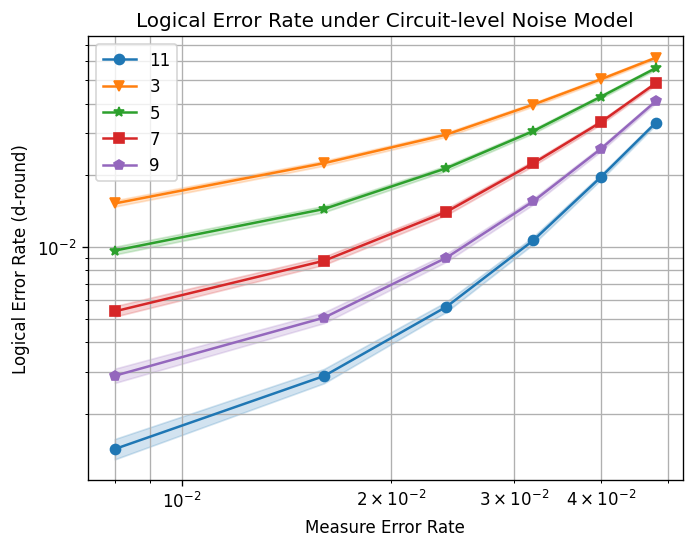

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['meas_error'],
    group_func=lambda stat: stat.json_metadata['distance'],
)

ax.loglog()
ax.set_title("Logical Error Rate under Circuit-level Noise Model")
ax.set_xlabel("Measure Error Rate")
ax.set_ylabel("Logical Error Rate (d-round)")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)
plt.show()

### Draw - Code distance vs. LER (for various measurement errors)

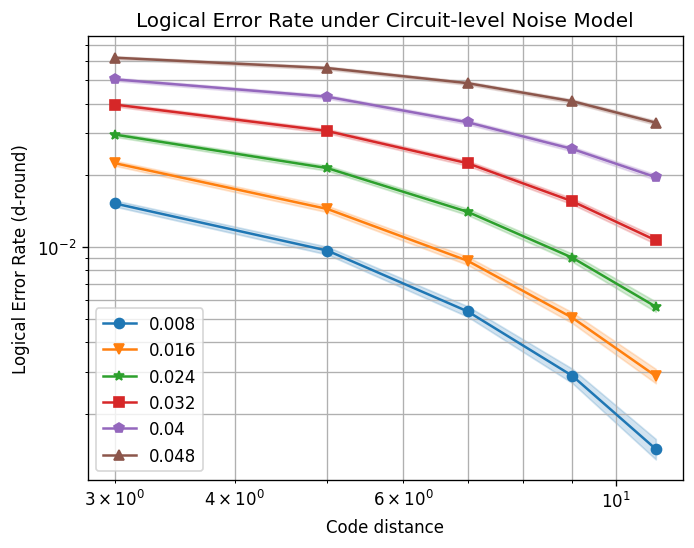

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['distance'],
    group_func=lambda stat: stat.json_metadata['meas_error'],
)

ax.loglog()
ax.set_title("Logical Error Rate under Circuit-level Noise Model")
ax.set_xlabel("Code distance")
ax.set_ylabel("Logical Error Rate (d-round)")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)
plt.show()

### Derive the required code distance to achieve the target LER

In [9]:
# input
target_ler = 1e-3

# parsing
grouped = defaultdict(list)
for s in stats:
    md = s.json_metadata
    ms_p = md.get('meas_error')  
    d = md.get('distance')
    ler = float(s.errors / s.shots)
    grouped[ms_p].append((d, ler))

# 
result = []
for ms_p, val_list in sorted(grouped.items()):
    d_list = [d for (d, _) in val_list]
    ler_list = [ler for (_, ler) in val_list]
    d_req = get_required_distance(target_ler, d_list, ler_list)
    pq_per_lq = 2*(d_req**2)-1
    result.append({"meas_error": ms_p, "d_req": d_req, "pq_per_lq": pq_per_lq})

for res in result:
    print(res)


{'meas_error': 0.008, 'd_req': 15, 'pq_per_lq': 449}
{'meas_error': 0.016, 'd_req': 17, 'pq_per_lq': 577}
{'meas_error': 0.024, 'd_req': 21, 'pq_per_lq': 881}
{'meas_error': 0.032, 'd_req': 27, 'pq_per_lq': 1457}
{'meas_error': 0.04, 'd_req': 39, 'pq_per_lq': 3041}
{'meas_error': 0.048, 'd_req': 59, 'pq_per_lq': 6961}
